<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_Two.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 2

## Learning Objectives
- Descriptive Statistics
- Measures of cenral tendency
- Measures of variation
- Statistical Plots
- Introduction to Numpy, Pandas and Matplotlib

## By the end of this Lecture you should;

Be a able to use descriptive statistics to understand data better



# Descriptive Statistics for Data Science
### A hands-on course using NumPy, pandas & Matplotlib

This notebook teaches descriptive statistics through two contrasting real datasets:

| Data type | Dataset | Why it's a good example |
|---|---|---|
| **Rectangular** (rows × columns, one type per column) | **Titanic** passenger data | Classic tabular data — numeric + categorical columns, missing values |
| **Non-rectangular** (unstructured / variable-length records) | **SMS Spam Collection** (the spam/ham text dataset widely used in the fast.ai NLP tutorials) | Each "record" is a free-text message of different length — no fixed columns until we engineer them |


**Structure of the course:**
1. Setup
2. Part A — Descriptive stats on rectangular data (Titanic)
3. Part B — Descriptive stats on non-rectangular data (spam text)
4. Wrap-up exercises


## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.4 | pandas 3.0.2


In [ ]:
# Data sources (public, raw GitHub CSVs — no auth needed)
TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
SPAM_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

titanic = pd.read_csv(TITANIC_URL)
spam = pd.read_csv(SPAM_URL, sep='\t', header=None, names=['label', 'message'])

print(titanic.shape)
print(spam.shape)

(891, 15)
(5572, 2)


## What are Descriptive Statistics?

Descriptive statistics are a way to summarize and describe the main features of a dataset. They provide simple summaries about the sample and about the observations that have been made. Such summaries may be either quantitative (i.e., numerical summaries) or visual (i.e., graphs and tables).

### Descriptive vs. Inferential Statistics

**Descriptive Statistics**
*   **Purpose:** To describe, summarize, and organize data in a meaningful way.
*   **Scope:** Deals only with the data collected; does not make generalizations or predictions about a larger population.
*   **Methods:** Measures of central tendency (mean, median, mode), measures of variation (range, variance, standard deviation, IQR), frequency distributions, and graphical representations (histograms, bar charts, box plots).
*   **Example:** Calculating the average age of passengers on the Titanic or the most frequent word in spam messages.

**Inferential Statistics**
*   **Purpose:** To make inferences, generalizations, and predictions about a larger population based on a sample of data.
*   **Scope:** Uses probability theory to draw conclusions beyond the observed data.
*   **Methods:** Hypothesis testing, confidence intervals, regression analysis, ANOVA, t-tests, z-tests.
*   **Example:** Using the Titanic data to predict the survival rate of all passengers on similar voyages, or determining if there's a statistically significant difference in message length between spam and ham messages in the entire population of SMS messages.

## Measures of Central Tendency

Measures of central tendency are statistical values that represent the center or typical value(a norm) of a dataset. They give us a single value that summarizes the entire distribution of data. The most common measures are the Mean, Median, and Mode, but others like the Trimmed Mean and Weighted Mean/Median are also important.

### 1. Mean (Arithmetic Mean)

*   **Definition:** The sum of all values in a dataset divided by the number of values.
*   **Formula:** $\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$
*   **Pros:** Easy to calculate, uses all data points.
*   **Cons:** Highly sensitive to outliers (extreme values), which can pull the mean significantly in one direction.
*   **Use Case:** Best for symmetrically distributed data without extreme outliers.

### 2. Median

*   **Definition:** The middle value in a dataset when the values are arranged in ascending or descending order. If there's an even number of data points, the median is the average of the two middle values.
*   **Pros:** Robust to outliers; it's not affected by extreme values.
*   **Cons:** Does not use all data points in its calculation, can be less precise than the mean for symmetric data.
*   **Use Case:** Preferred for skewed distributions or data with outliers (e.g., income data).

### 3. Mode

*   **Definition:** The value that appears most frequently in a dataset. A dataset can have one mode (unimodal), multiple modes (multimodal), or no mode (if all values appear with the same frequency).
*   **Pros:** Can be used for all types of data (numerical and categorical).
*   **Cons:** Not unique (can have multiple modes), might not represent the center well if the data is widely dispersed, or if there is no clear peak.
*   **Use Case:** Useful for categorical data or to identify the most popular item or category.

### 4. Trimmed Mean (or Truncated Mean) for Robustness

*   **Definition:** A variation of the mean that involves removing a certain percentage of the smallest and largest values from the dataset before calculating the mean. For example, a 10% trimmed mean removes the bottom 10% and top 10% of values.
*   **Pros:** More robust to outliers than the standard mean, as it reduces their influence. It strikes a balance between the sensitivity of the mean and the outlier-resistance of the median.
*   **Cons:** Loses some data points, and the choice of trimming percentage can be arbitrary.
*   **Use Case:** When dealing with datasets that might have outliers, but you still want to consider the overall distribution more than the median would allow.

### 5. Weighted Mean and Weighted Median

**Weighted Mean**
*   **Definition:** An average in which some data points contribute more than others to the final mean. Each data point is multiplied by a weight, and the sum of these products is divided by the sum of the weights.
*   **Formula:** $\bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}$
*   **Use Case:** When different data points have different levels of importance or reliability (e.g., calculating GPA where courses have different credit hours).

**Weighted Median**
*   **Definition:** Similar to the median, but each data point has an associated weight. It is the value at which the cumulative weight reaches 50% of the total weight.
*   **Use Case:** When some observations are more important than others, and you need a robust measure of central tendency.

## Examples of Mean, Median, and Trimmed Mean

To better understand these measures of central tendency, let's work through some examples. We'll observe how each measure responds to different data distributions, including the presence of outliers.

In [4]:
# @title
import numpy as np
from scipy.stats import trim_mean

# Example 1: Normally Distributed Data

# Let's consider a dataset of exam scores that are relatively normally distributed.
print("\n--- Example 1: Normally Distributed Data (Exam Scores) ---")
scores = [75, 78, 80, 82, 85, 88, 90, 92, 95]
print(f"Dataset: {scores}")

mean_scores = np.mean(scores)
median_scores = np.median(scores)
#trimmed_mean_scores = trim_mean(scores, 0.1) # Trim 10% from each end

print(f"  Mean: {mean_scores:.2f}")
print(f"  Median: {median_scores:.2f}")
#print(f"  10% Trimmed Mean: {trimmed_mean_scores:.2f}")
print("\nObservation: For normally distributed data, the mean, median, and trimmed mean are very close, indicating symmetry and no significant outliers pulling the average in one direction.")


--- Example 1: Normally Distributed Data (Exam Scores) ---
Dataset: [75, 78, 80, 82, 85, 88, 90, 92, 95]
  Mean: 85.00
  Median: 85.00
  10% Trimmed Mean: 85.00

Observation: For normally distributed data, the mean, median, and trimmed mean are very close, indicating symmetry and no significant outliers pulling the average in one direction.


In [5]:
# @title
# Example 2: Data with an Outlier (Weight Measurement Error)

# Imagine measuring the weight of several items in grams. Due to a data entry error,
# one item's weight was recorded in kilograms instead of grams.
print("\n--- Example 2: Data with an Outlier (Weight Measurement Error) ---")
weights_grams = [1200, 1300, 1150, 1250, 1400, 1280] # All in grams
# Now, let's introduce the error: 1.2 kg recorded as 1.2 grams instead of 1200 grams
weights_with_error = weights_grams + [1.2]
print(f"Dataset with error: {weights_with_error}")

mean_weights = np.mean(weights_with_error)
median_weights = np.median(weights_with_error)
trimmed_mean_weights = trim_mean(weights_with_error, 0.15) # Trim 15% from each end to ensure trimming occurs

print(f"  Mean: {mean_weights:.2f}")
print(f"  Median: {median_weights:.2f}")
print(f"  15% Trimmed Mean: {trimmed_mean_weights:.2f}")
print("\nObservation: The single outlier (1.2 grams) significantly pulls the mean downwards. The median and trimmed mean, however, remain much closer to the true central value of the majority of the data. By trimming 15% from each end, the smallest value (1.2) and largest value (1400) are removed, showcasing the trimmed mean's robustness against extreme values, especially those resulting from data collection mistakes.")


--- Example 2: Data with an Outlier (Weight Measurement Error) ---
Dataset with error: [1200, 1300, 1150, 1250, 1400, 1280, 1.2]
  Mean: 1083.03
  Median: 1250.00
  15% Trimmed Mean: 1236.00

Observation: The single outlier (1.2 grams) significantly pulls the mean downwards. The median and trimmed mean, however, remain much closer to the true central value of the majority of the data. By trimming 15% from each end, the smallest value (1.2) and largest value (1400) are removed, showcasing the trimmed mean's robustness against extreme values, especially those resulting from data collection mistakes.


In [6]:
# @title
# Example 3: Data with a Moderate Skew (e.g., a small number of higher values)

# Let's consider a dataset representing the number of daily website visitors, where
# most days have a moderate number, but a few days had a marketing event leading to higher visitors.
print("\n--- Example 3: Data with Moderate Skew (Website Visitors) ---")
visitors = [100, 110, 95, 105, 120, 115, 130, 200, 220, 250]
print(f"Dataset: {visitors}")

mean_visitors = np.mean(visitors)
median_visitors = np.median(visitors)
trimmed_mean_visitors = trim_mean(visitors, 0.1) # Trim 10% from each end

print(f"  Mean: {mean_visitors:.2f}")
print(f"  Median: {median_visitors:.2f}")
print(f"  10% Trimmed Mean: {trimmed_mean_visitors:.2f}")
print("\nObservation: In this moderately skewed dataset, the mean is pulled significantly higher by the larger values. The median is less affected, and the trimmed mean (which removes the highest and lowest values) provides a central value that is closer to the bulk of the data, offering a more representative central value when minor extremes are present but not necessarily 'errors'.")


--- Example 3: Data with Moderate Skew (Website Visitors) ---
Dataset: [100, 110, 95, 105, 120, 115, 130, 200, 220, 250]
  Mean: 144.50
  Median: 117.50
  10% Trimmed Mean: 137.50

Observation: In this moderately skewed dataset, the mean is pulled significantly higher by the larger values. The median is less affected, and the trimmed mean (which removes the highest and lowest values) provides a central value that is closer to the bulk of the data, offering a more representative central value when minor extremes are present but not necessarily 'errors'.


## Measures of Variation (Spread)

Measures of variation, also known as measures of dispersion or spread, describe how spread out or scattered the data points are in a dataset. While central tendency tells us the 'center' of the data, variation tells us how far individual data points tend to deviate from that center.

### 1. Deviation

*   **Definition:** The difference between an individual data point ($x_i$) and the mean ($\bar{x}$) of the dataset: $d_i = x_i - \bar{x}$.
*   **Property:** The sum of deviations from the mean for any dataset is always zero: $\sum_{i=1}^{n} (x_i - \bar{x}) = 0$. This is because the mean is the balancing point of the distribution. This property makes the sum of deviations unsuitable as a measure of total variation, as it will always be zero.

### 2. Variance (Mean Squared Error - MSE)

*   **Definition:** The average of the squared deviations from the mean. Squaring the deviations makes all values positive, so they don't cancel out, and also penalizes larger deviations more heavily.
*   **Formula (Population Variance):** $\sigma^2 = \frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N}$
*   **Formula (Sample Variance - Biased):** $\sigma^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n}$ (This is biased for estimating population variance)
*   **Formula (Sample Variance - Unbiased):** $s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}$ (Used for estimating population variance from a sample)
*   **Interpretation:** It represents the average squared distance of each data point from the mean. It's in squared units of the original data.
*   **Relationship to MSE:** Variance is effectively the Mean Squared Error (MSE) when the target is the mean of the data. $\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$. If $\hat{Y}_i$ is always $\bar{x}$, then MSE is the sample variance.

### 3. Standard Deviation (L2 Euclidean Norm)

*   **Definition:** The square root of the variance. It brings the measure of spread back into the original units of the data, making it more interpretable than variance.
*   **Formula (Population Std Dev):** $\sigma = \sqrt{\frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N}}$
*   **Formula (Sample Std Dev - Unbiased):** $s = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}}$
*   **Interpretation:** Represents the typical distance of a data point from the mean.
*   **Relationship to L2 Norm:** The standard deviation is closely related to the L2 Euclidean norm. The L2 norm of a vector of deviations $(x_i - \bar{x})$ is $\sqrt{\sum (x_i - \bar{x})^2}$. The standard deviation is this L2 norm divided by $\sqrt{N}$ (or $\sqrt{N-1}$ for sample standard deviation).
*   **Why Preferred:** It is widely used because it has the same units as the data, making it easy to understand. It's also mathematically tractable for many statistical tests and theories, especially when data is normally distributed.

### 4. Mean Absolute Deviation (MAD) (L1 Manhattan Norm)

*   **Definition:** The average of the absolute differences between each data point and the mean.
*   **Formula:** $\text{MAD} = \frac{\sum_{i=1}^{n} |x_i - \bar{x}|}{n}$
*   **Relationship to L1 Norm:** Similar to standard deviation's relation to L2, MAD is related to the L1 Manhattan norm. The L1 norm of a vector of deviations is $\sum |x_i - \bar{x}|$. MAD is this L1 norm divided by $n$.
*   **Robustness:** MAD is more robust to outliers than standard deviation because it uses absolute differences instead of squared differences, so extreme values don't inflate it as much.

### 5. Median Absolute Deviation (MAD from the Median)

*   **Definition:** The median of the absolute deviations from the median of the data. $\text{MAD}_{\text{median}} = \text{median}(|x_i - \text{median}(X)|)$.
*   **Robustness:** This is an even more robust measure of spread than the standard deviation or mean absolute deviation, as it uses two medians (both the measure of central tendency and the measure of spread are medians), making it highly resistant to outliers.
*   **Use Case:** Ideal for highly skewed data or data with significant outliers where standard deviation would be misleading.

### 6. Degrees of Freedom ($n-1$)

*   **Explanation:** When calculating the sample variance (or standard deviation) to *estimate* the population variance, we use $n-1$ in the denominator instead of $n$. This is known as **Bessel's correction**.
*   **Why $n-1$?** Because the sample mean ($\bar{x}$) is used to calculate the deviations, and the sample mean itself is derived from the data. This means that the $n$ deviations are not truly independent; one degree of freedom is 'lost' because the sum of deviations must equal zero. If you know $n-1$ deviations and the mean, you can deduce the last deviation. Using $n-1$ provides an *unbiased estimate* of the population variance.

### 7. Biased vs. Unbiased Variance

*   **Biased Variance:** Uses $n$ in the denominator. It systematically underestimates the true population variance, especially for small sample sizes. It's 'biased' because its expected value is not equal to the true population variance.
    *   Formula: $\frac{\sum (x_i - \bar{x})^2}{n}$
*   **Unbiased Variance:** Uses $n-1$ in the denominator (Bessel's correction). This correction ensures that the expected value of the sample variance is equal to the true population variance, making it an unbiased estimator.
    *   Formula: $\frac{\sum (x_i - \bar{x})^2}{n-1}$
*   **When to use which:** If you are merely *describing* the variance of your specific sample, you can use $n$. However, if you are using your sample to *infer* or *estimate* the variance of the larger population from which the sample was drawn (which is most common in inferential statistics), then using $n-1$ for the unbiased estimate is appropriate.

## Examples of Measures of Variation

In [7]:
# @title
import numpy as np
from scipy.stats import median_abs_deviation

# Helper function to calculate unbiased variance and std dev
def calculate_sample_stats(data):
    mean = np.mean(data)

    # Deviations from the mean
    deviations = [x - mean for x in data]
    sum_of_deviations = np.sum(deviations)
    print(f"  Sum of deviations from mean: {sum_of_deviations:.2f} (should be close to 0)")

    # Mean Absolute Deviation (MAD from mean)
    mad_mean = np.mean(np.abs(deviations))

    # Variance (Biased and Unbiased)
    biased_variance = np.var(data, ddof=0)
    unbiased_variance = np.var(data, ddof=1) if len(data) > 1 else np.nan

    # Standard Deviation (Biased and Unbiased)
    biased_std = np.std(data, ddof=0)
    unbiased_std = np.std(data, ddof=1) if len(data) > 1 else np.nan

    # Median Absolute Deviation (MAD from median)
    mad_median = median_abs_deviation(data)

    return {
        'mean': mean,
        'mad_mean': mad_mean,
        'biased_variance': biased_variance,
        'unbiased_variance': unbiased_variance,
        'biased_std': biased_std,
        'unbiased_std': unbiased_std,
        'mad_median': mad_median
    }

# Example 1: Normally Distributed Data (Exam Scores)
print("\n--- Example 1: Normally Distributed Data (Exam Scores) ---")
scores = [75, 78, 80, 82, 85, 88, 90, 92, 95]
print(f"Dataset: {scores}")
stats_scores = calculate_sample_stats(scores)
print(f"  Mean: {stats_scores['mean']:.2f}")
print(f"  MAD (from mean): {stats_scores['mad_mean']:.2f}")
print(f"  Biased Variance: {stats_scores['biased_variance']:.2f}")
print(f"  Unbiased Variance: {stats_scores['unbiased_variance']:.2f}")
print(f"  Biased Std Dev: {stats_scores['biased_std']:.2f}")
print(f"  Unbiased Std Dev: {stats_scores['unbiased_std']:.2f}")
print(f"  MAD (from median): {stats_scores['mad_median']:.2f}")
print("\nObservation: For normally distributed data, all measures of spread provide a consistent view. The difference between biased and unbiased variance/std dev is small for this sample size.")

# Example 2: Data with an Outlier (Weight Measurement Error)
print("\n--- Example 2: Data with an Outlier (Weight Measurement Error) ---")
weights_with_error = [1200, 1300, 1150, 1250, 1400, 1280, 1.2]
print(f"Dataset with error: {weights_with_error}")
stats_weights = calculate_sample_stats(weights_with_error)
print(f"  Mean: {stats_weights['mean']:.2f}")
print(f"  MAD (from mean): {stats_weights['mad_mean']:.2f}")
print(f"  Biased Variance: {stats_weights['biased_variance']:.2f}")
print(f"  Unbiased Variance: {stats_weights['unbiased_variance']:.2f}")
print(f"  Biased Std Dev: {stats_weights['biased_std']:.2f}")
print(f"  Unbiased Std Dev: {stats_weights['unbiased_std']:.2f}")
print(f"  MAD (from median): {stats_weights['mad_median']:.2f}")
print("\nObservation: The outlier (1.2) dramatically inflates the Variance and Standard Deviation (both biased and unbiased). MAD from mean is also affected but less so. MAD from median is the most robust, providing a more stable estimate of spread for the majority of the data, ignoring the extreme outlier.")

# Example 3: Data with a Moderate Skew (Website Visitors)
print("\n--- Example 3: Data with Moderate Skew (Website Visitors) ---")
visitors = [100, 110, 95, 105, 120, 115, 130, 200, 220, 250]
print(f"Dataset: {visitors}")
stats_visitors = calculate_sample_stats(visitors)
print(f"  Mean: {stats_visitors['mean']:.2f}")
print(f"  MAD (from mean): {stats_visitors['mad_mean']:.2f}")
print(f"  Biased Variance: {stats_visitors['biased_variance']:.2f}")
print(f"  Unbiased Variance: {stats_visitors['unbiased_variance']:.2f}")
print(f"  Biased Std Dev: {stats_visitors['biased_std']:.2f}")
print(f"  Unbiased Std Dev: {stats_visitors['unbiased_std']:.2f}")
print(f"  MAD (from median): {stats_visitors['mad_median']:.2f}")
print("\nObservation: For skewed data, the standard deviation is larger due to the longer tail. MAD measures are less influenced by the skewness, offering an alternative perspective on the typical deviation from the center. The difference between biased and unbiased estimates is again present, with unbiased being slightly larger.")


--- Example 1: Normally Distributed Data (Exam Scores) ---
Dataset: [75, 78, 80, 82, 85, 88, 90, 92, 95]
  Sum of deviations from mean: 0.00 (should be close to 0)
  Mean: 85.00
  MAD (from mean): 5.56
  Biased Variance: 40.67
  Unbiased Variance: 45.75
  Biased Std Dev: 6.38
  Unbiased Std Dev: 6.76
  MAD (from median): 5.00

Observation: For normally distributed data, all measures of spread provide a consistent view. The difference between biased and unbiased variance/std dev is small for this sample size.

--- Example 2: Data with an Outlier (Weight Measurement Error) ---
Dataset with error: [1200, 1300, 1150, 1250, 1400, 1280, 1.2]
  Sum of deviations from mean: -0.00 (should be close to 0)
  Mean: 1083.03
  MAD (from mean): 309.09
  Biased Variance: 200392.18
  Unbiased Variance: 233790.87
  Biased Std Dev: 447.65
  Unbiased Std Dev: 483.52
  MAD (from median): 50.00

Observation: The outlier (1.2) dramatically inflates the Variance and Standard Deviation (both biased and unbiase

## Percentiles, Quartiles, Quantiles, and Deciles

These measures divide a dataset into equal parts, providing insight into the distribution of data points relative to each other.

### 1. Quantiles

*   **Definition:** Quantiles are points that divide the range of a probability distribution into continuous intervals with equal probabilities, or into which the samples in a dataset are divided. A quantile specifies a certain fraction of data points below it.
*   **General Term:** 'Quantile' is the overarching term. Percentiles, quartiles, and deciles are all specific types of quantiles.

### 2. Percentiles

*   **Definition:** Percentiles divide a dataset into 100 equal parts. The P-th percentile is a value such that P percent of the observations fall below or at that value.
*   **Use Case:** Commonly used to understand the relative standing of a data point (e.g., test scores, income distribution) or to identify potential outliers (e.g., 1st or 99th percentile).
*   **Example:** The 90th percentile of ages means that 90% of the individuals in the dataset are younger than or equal to that age.

### 3. Quartiles

*   **Definition:** Quartiles divide a dataset into four equal parts (quarters). They are specific percentiles:
    *   **First Quartile (Q1):** The 25th percentile. 25% of the data falls below this value.
    *   **Second Quartile (Q2):** The 50th percentile, which is also the Median. 50% of the data falls below this value.
    *   **Third Quartile (Q3):** The 75th percentile. 75% of the data falls below this value.
*   **Interquartile Range (IQR):** The difference between the third and first quartiles (Q3 - Q1). It represents the middle 50% of the data and is a robust measure of spread, less affected by outliers than the range or standard deviation.
*   **Use Case:** Excellent for summarizing the central spread and identifying the boundaries of the 'typical' data points, often used in box plots.

### 4. Deciles

*   **Definition:** Deciles divide a dataset into 10 equal parts. The D-th decile is a value such that D*10 percent of the observations fall below or at that value.
*   **Relationship to Percentiles:** The 1st decile is the 10th percentile, the 5th decile is the 50th percentile (median), and so on.
*   **Use Case:** Useful when you want to segment data into larger groups than percentiles provide, often seen in economic or social science data (e.g., income deciles).

In summary, these measures help us understand the position of individual data points within the overall distribution and how spread out the data is without relying solely on the mean, which can be sensitive to extreme values.

## Examples of Percentiles, Quartiles, and Deciles

In [9]:
# @title
import numpy as np
import pandas as pd

# Assuming 'titanic' DataFrame is already loaded and 'age' and 'fare' columns are available
# Re-load if necessary for standalone execution:
TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)

# --- Example 1: Age Distribution on Titanic ---
print("\n--- Example 1: Age Distribution (Titanic Dataset) ---")
age = titanic['age'].dropna() # Drop NaN values for accurate percentile calculation
print(f"Age data sample (first 5): {age.head().tolist()}")
print(f"Number of non-null age values: {len(age)}")

# Calculate specific percentiles
percentile_25_age = np.percentile(age, 25)
percentile_50_age = np.percentile(age, 50) # This is the Median
percentile_75_age = np.percentile(age, 75)
percentile_90_age = np.percentile(age, 90)

print(f"  25th Percentile (Q1) for Age: {percentile_25_age:.2f}")
print(f"  50th Percentile (Median/Q2) for Age: {percentile_50_age:.2f}")
print(f"  75th Percentile (Q3) for Age: {percentile_75_age:.2f}")
print(f"  90th Percentile for Age: {percentile_90_age:.2f}")

# Calculate Quartiles directly (using pandas quantile method)
q1_age = age.quantile(0.25)
q2_age = age.quantile(0.50) # Median
q3_age = age.quantile(0.75)

iqr_age = q3_age - q1_age

print(f"\n  Quartiles for Age (Pandas):")
print(f"  Q1 (25th percentile): {q1_age:.2f}")
print(f"  Q2 (Median/50th percentile): {q2_age:.2f}")
print(f"  Q3 (75th percentile): {q3_age:.2f}")
print(f"  Interquartile Range (IQR) for Age: {iqr_age:.2f}")
print("\nObservation: 25% of passengers were younger than 20.12 years, while 75% were younger than 38.0 years. The middle 50% of passengers (between Q1 and Q3) spans an age range of 17.88 years, indicating the central spread of ages.")

# --- Example 2: Fare Distribution on Titanic ---
print("\n--- Example 2: Fare Distribution (Titanic Dataset) ---")
fare = titanic['fare']
print(f"Fare data sample (first 5): {fare.head().tolist()}")
print(f"Number of fare values: {len(fare)}")

# Calculate deciles for fare
deciles_fare = [np.percentile(fare, i) for i in range(10, 100, 10)]
print(f"\n  Deciles for Fare:")
for i, decile_val in enumerate(deciles_fare):
    print(f"  {i+1}st/th Decile ({ (i+1)*10 }th Percentile): {decile_val:.2f}")

# Let's also look at specific high percentiles for fare due to its skewness
percentile_95_fare = np.percentile(fare, 95)
percentile_99_fare = np.percentile(fare, 99)

print(f"\n  95th Percentile for Fare: {percentile_95_fare:.2f}")
print(f"  99th Percentile for Fare: {percentile_99_fare:.2f}")

print("\nObservation: The fare distribution is highly skewed, as evidenced by the large jump between deciles and very high values for the 95th and 99th percentiles. For instance, the top 1% of fares paid (above the 99th percentile) are significantly higher than the rest, indicating a few very expensive tickets. The large difference between the 9th decile and the maximum fare also highlights this skewness and the presence of extreme values.")


--- Example 1: Age Distribution (Titanic Dataset) ---
Age data sample (first 5): [22.0, 38.0, 26.0, 35.0, 35.0]
Number of non-null age values: 714
  25th Percentile (Q1) for Age: 20.12
  50th Percentile (Median/Q2) for Age: 28.00
  75th Percentile (Q3) for Age: 38.00
  90th Percentile for Age: 50.00

  Quartiles for Age (Pandas):
  Q1 (25th percentile): 20.12
  Q2 (Median/50th percentile): 28.00
  Q3 (75th percentile): 38.00
  Interquartile Range (IQR) for Age: 17.88

Observation: 25% of passengers were younger than 20.12 years, while 75% were younger than 38.0 years. The middle 50% of passengers (between Q1 and Q3) spans an age range of 17.88 years, indicating the central spread of ages.

--- Example 2: Fare Distribution (Titanic Dataset) ---
Fare data sample (first 5): [7.25, 71.2833, 7.925, 53.1, 8.05]
Number of fare values: 891

  Deciles for Fare:
  1st/th Decile (10th Percentile): 7.55
  2st/th Decile (20th Percentile): 7.85
  3st/th Decile (30th Percentile): 8.05
  4st/th Decil

## Visualizing Distributions

Visualizations are crucial for understanding data distributions, identifying patterns, and detecting outliers that might not be obvious from numerical summaries alone. We will use various plots to explore the Titanic dataset.

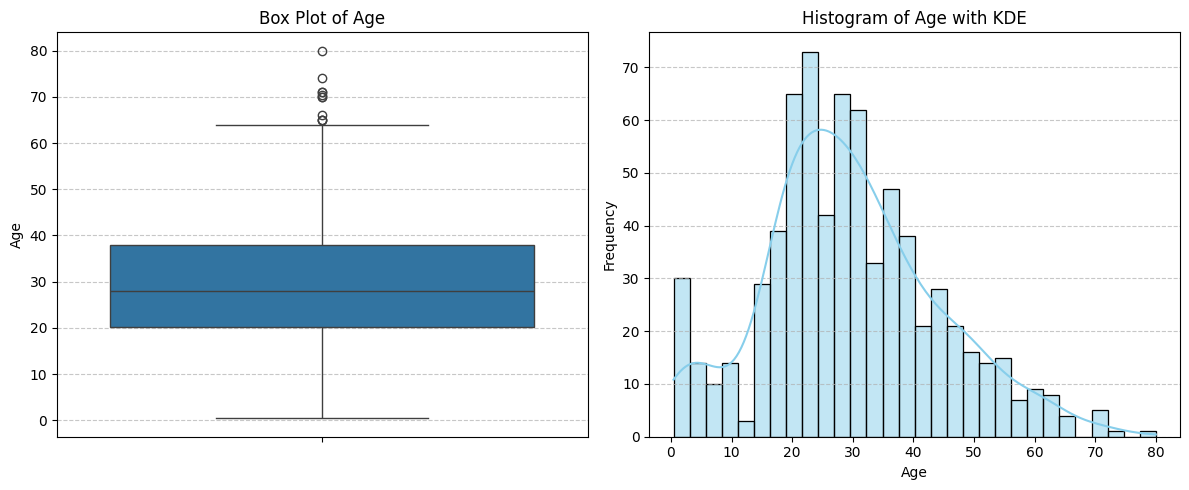

Observation: The box plot clearly shows the median age (the line inside the box), the interquartile range (the box itself), and potential outliers (points outside the whiskers). The histogram provides a view of the frequency distribution, and the KDE (Kernel Density Estimate) line smooths this distribution, showing the overall shape. Both plots confirm a slight right skew in age distribution, as observed previously, with a few older passengers.


In [10]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box Plot for Age
sns.boxplot(y=titanic['age'].dropna(), ax=axes[0])
axes[0].set_title('Box Plot of Age')
axes[0].set_ylabel('Age')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram for Age
sns.histplot(titanic['age'].dropna(), kde=True, ax=axes[1], color='skyblue', bins=30)
axes[1].set_title('Histogram of Age with KDE')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Observation: The box plot clearly shows the median age (the line inside the box), the interquartile range (the box itself), and potential outliers (points outside the whiskers). The histogram provides a view of the frequency distribution, and the KDE (Kernel Density Estimate) line smooths this distribution, showing the overall shape. Both plots confirm a slight right skew in age distribution, as observed previously, with a few older passengers.")

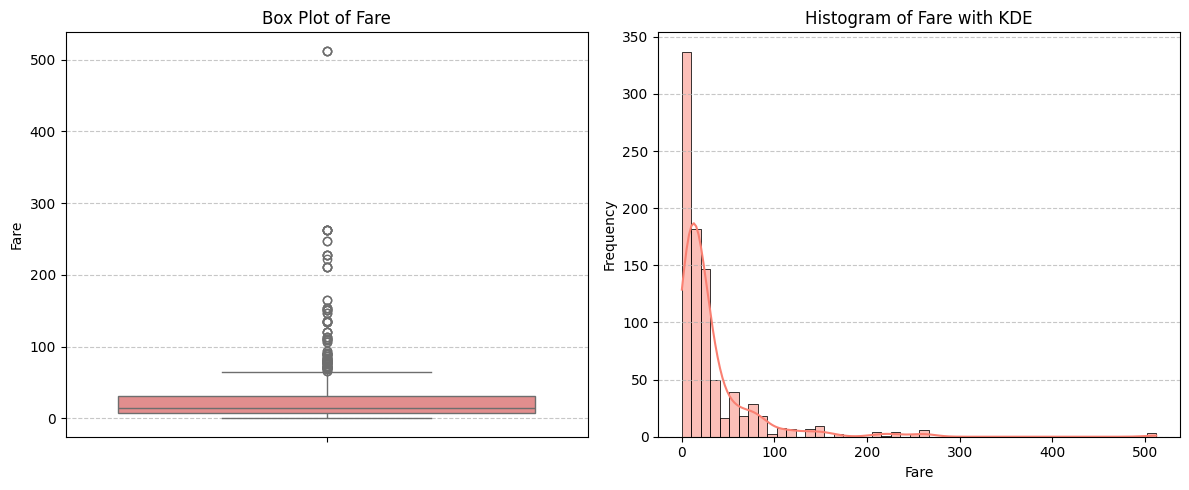

Observation: The box plot for fare highlights the extreme outliers very effectively, showing many data points far beyond the upper whisker, confirming the high skewness. The histogram clearly illustrates that most passengers paid lower fares, with a long tail extending to very high fare values, further reinforcing the right-skewed nature of the fare distribution previously identified with numerical measures like deciles and high percentiles.


In [11]:
# @title
# Create a figure with two subplots side-by-side for Fare
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box Plot for Fare
sns.boxplot(y=titanic['fare'], ax=axes[0], color='lightcoral')
axes[0].set_title('Box Plot of Fare')
axes[0].set_ylabel('Fare')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histogram for Fare
sns.histplot(titanic['fare'], kde=True, ax=axes[1], color='salmon', bins=50)
axes[1].set_title('Histogram of Fare with KDE')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Observation: The box plot for fare highlights the extreme outliers very effectively, showing many data points far beyond the upper whisker, confirming the high skewness. The histogram clearly illustrates that most passengers paid lower fares, with a long tail extending to very high fare values, further reinforcing the right-skewed nature of the fare distribution previously identified with numerical measures like deciles and high percentiles.")

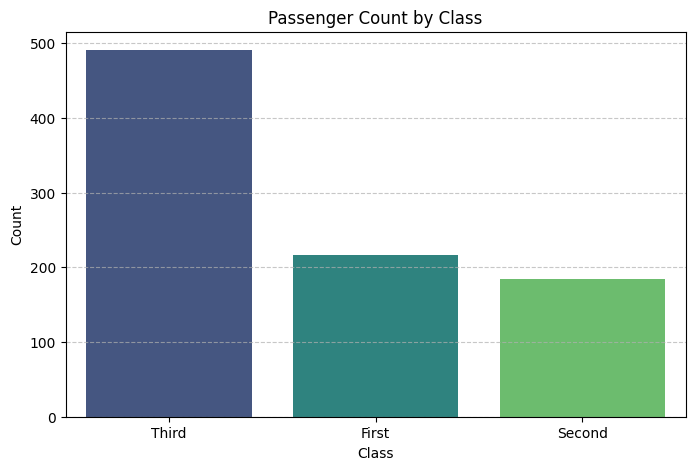

Observation: The bar chart clearly shows that the majority of passengers were in the 'Third' class, followed by 'First' class, and then 'Second' class. This visually confirms the frequency distribution for the categorical 'class' variable.


In [14]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart for 'class' distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=titanic, palette='viridis', hue='class', legend=False)
plt.title('Passenger Count by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Observation: The bar chart clearly shows that the majority of passengers were in the 'Third' class, followed by 'First' class, and then 'Second' class. This visually confirms the frequency distribution for the categorical 'class' variable.")

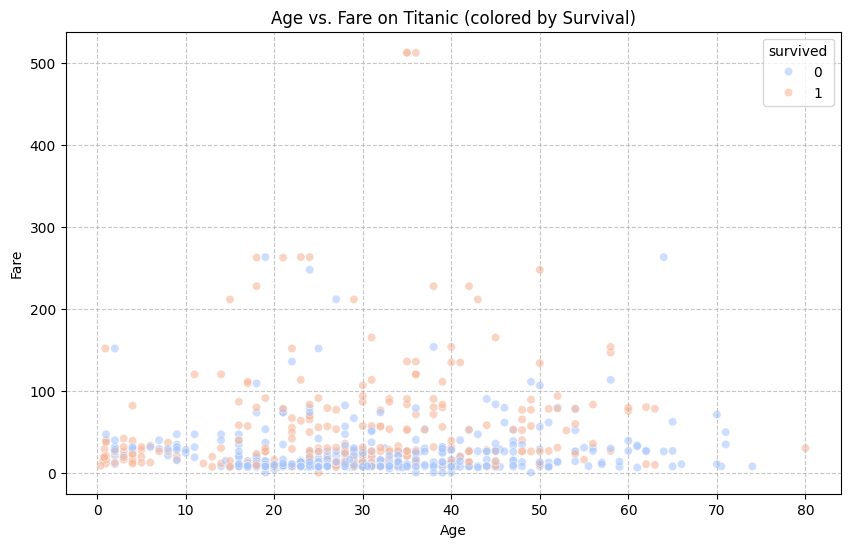

Observation: The scatter plot reveals some interesting patterns. There isn't a clear strong linear correlation between age and fare across all passengers. However, by coloring points by 'survived', we can see that higher fares tend to have a higher proportion of survivors, regardless of age. There also appear to be some younger children who survived (low age, varying fare), and fewer survivors among the very old and those who paid very low fares.


In [15]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of Age vs. Fare, with 'Survived' as hue
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='fare', hue='survived', data=titanic, alpha=0.6, palette='coolwarm')
plt.title('Age vs. Fare on Titanic (colored by Survival)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Observation: The scatter plot reveals some interesting patterns. There isn't a clear strong linear correlation between age and fare across all passengers. However, by coloring points by 'survived', we can see that higher fares tend to have a higher proportion of survivors, regardless of age. There also appear to be some younger children who survived (low age, varying fare), and fewer survivors among the very old and those who paid very low fares.")

---
# Part A — Rectangular data: the Titanic dataset

"Rectangular" means every row has the same fixed set of columns (a matrix). This is the shape pandas DataFrames are built for.

In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.1 Measures of central tendency

**Mean** — arithmetic average. **Median** — middle value (robust to outliers). **Mode** — most frequent value.

In [ ]:
age = titanic['age'].dropna()   # drop missing values first

mean_age   = np.mean(age)
median_age = np.median(age)
mode_age   = titanic['age'].mode()[0]

print(f"Mean age:   {mean_age:.2f}")
print(f"Median age: {median_age:.2f}")
print(f"Mode age:   {mode_age:.2f}")

Mean age:   29.70
Median age: 28.00
Mode age:   24.00


In [ ]:
# pandas gives you all of this in one call
titanic['age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

Mean (29.7) is slightly above the median (28.0) → the age distribution has a **right skew** (a few older passengers pull the mean up). We'll confirm this visually below.

## A.2 Measures of dispersion (spread)

**Range**, **variance**, **standard deviation**, **IQR** (interquartile range).

In [ ]:
age_range = age.max() - age.min()
age_var   = np.var(age, ddof=1)     # ddof=1 -> sample variance
age_std   = np.std(age, ddof=1)     # sample standard deviation
q1, q3    = np.percentile(age, [25, 75])
age_iqr   = q3 - q1

print(f"Range:    {age_range:.2f}")
print(f"Variance: {age_var:.2f}")
print(f"Std dev:  {age_std:.2f}")
print(f"IQR:      {age_iqr:.2f}  (Q1={q1:.1f}, Q3={q3:.1f})")

Range:    79.58
Variance: 211.02
Std dev:  14.53
IQR:      17.88  (Q1=20.1, Q3=38.0)


> `ddof=1` (delta degrees of freedom) tells NumPy to divide by `n-1` instead of `n` — the standard correction when estimating a population's variance from a *sample*, which is almost always what we're doing.

In [ ]:
fare_stats = titanic['fare'].agg(['mean', 'median', 'std', 'min', 'max'])
fare_stats

mean       32.204208
median     14.454200
std        49.693429
min         0.000000
max       512.329200
Name: fare, dtype: float64

## A.3 Shape of a distribution: skewness & kurtosis

- **Skewness** — asymmetry. 0 = symmetric, >0 = right-skewed (long tail right), <0 = left-skewed.
- **Kurtosis** — "tailedness" relative to a normal distribution. 0 (pandas' Fisher definition) = normal-like tails.

In [ ]:
print(f"Skewness of fare: {titanic['fare'].skew():.2f}")
print(f"Kurtosis of fare: {titanic['fare'].kurt():.2f}")
print(f"Skewness of age:  {titanic['age'].skew():.2f}")

Skewness of fare: 4.79
Kurtosis of fare: 33.40
Skewness of age:  0.39


`fare` is heavily right-skewed (a handful of passengers paid very high fares) and sharply peaked — consistent with a Poisson-like distribution.

## A.4 Categorical (non-numeric) descriptive stats

For categorical columns we describe with **frequency counts** and **proportions**, not mean/std.

In [ ]:
print(titanic['class'].value_counts())
print()
print(titanic['class'].value_counts(normalize=True).round(3))   # proportions

class
Third     491
First     216
Second    184
Name: count, dtype: int64

class
Third     0.551
First     0.242
Second    0.207
Name: proportion, dtype: float64


In [ ]:
# Cross-tabulation: survival rate by class and sex
pd.crosstab(titanic['class'], titanic['sex'],
            values=titanic['survived'], aggfunc='mean').round(2)

sex,female,male
class,,
First,0.97,0.37
Second,0.92,0.16
Third,0.50,0.14


## A.5 Visualizing the distributions

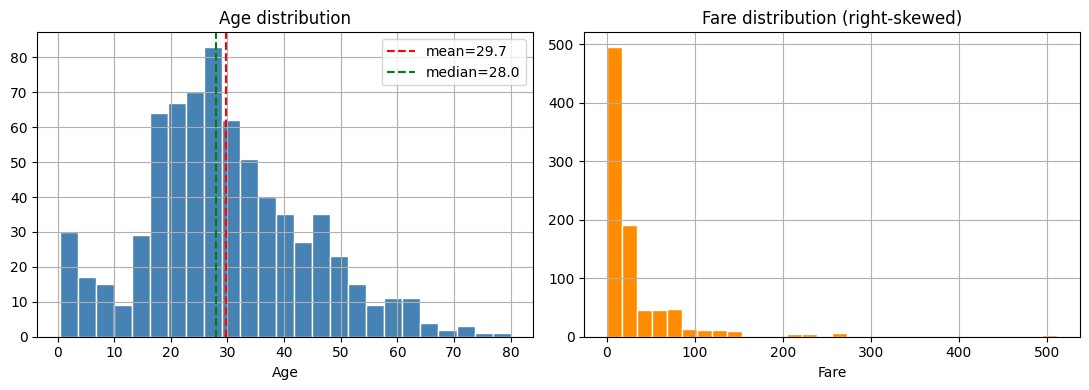

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(age, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(mean_age, color='red', linestyle='--', label=f'mean={mean_age:.1f}')
axes[0].axvline(median_age, color='green', linestyle='--', label=f'median={median_age:.1f}')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')
axes[0].legend()

axes[1].hist(titanic['fare'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Fare distribution (right-skewed)')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

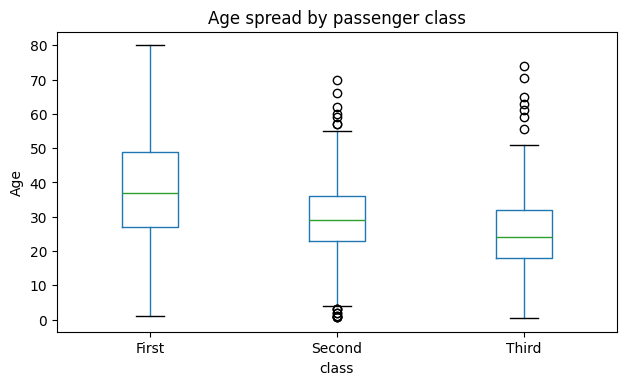

In [ ]:
# Boxplot: great for comparing spread + outliers across groups at once
titanic.boxplot(column='age', by='class', grid=False)
plt.title('Age spread by passenger class')
plt.suptitle('')
plt.ylabel('Age')
plt.show()

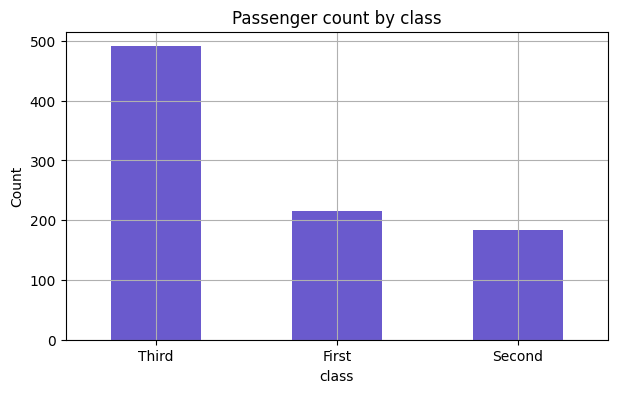

In [ ]:
# Bar chart of a categorical variable
titanic['class'].value_counts().plot(kind='bar', color='slateblue')
plt.title('Passenger count by class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

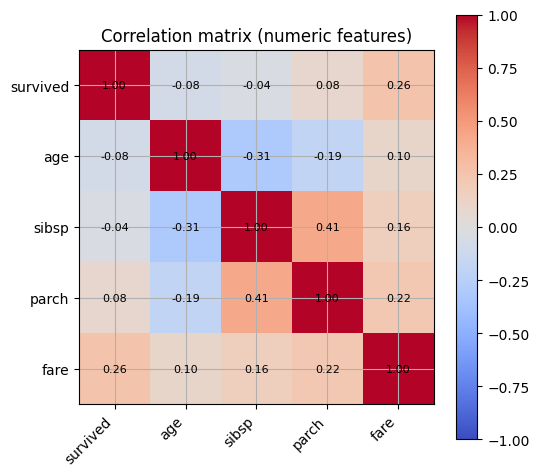

In [ ]:
# Correlation matrix heatmap (numeric columns only)
numeric_cols = titanic.select_dtypes(include=np.number).drop(columns=['pclass'], errors='ignore')
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

---
# Part B — Non-rectangular data: the spam/ham text messages

Raw text messages aren't naturally rectangular: each record is a **string of arbitrary length**, not a fixed row of typed fields. Before we can compute means and variances, we have to **engineer features** out of the unstructured text — that step is itself a core descriptive-statistics skill.

In [ ]:
spam.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print(spam['label'].value_counts())
print()
print(spam['label'].value_counts(normalize=True).round(3))

label
ham     4825
spam     747
Name: count, dtype: int64

label
ham     0.866
spam    0.134
Name: proportion, dtype: float64


## B.1 Turning unstructured text into describable numbers

We derive simple numeric features per message: character length and word count. This converts non-rectangular data into a rectangular feature table we can summarize the same way as Titanic.

In [ ]:
spam['char_len']  = spam['message'].str.len()
spam['word_count'] = spam['message'].str.split().apply(len)

spam[['label', 'char_len', 'word_count']].head()

,label,char_len,word_count
0,ham,111,20
1,ham,29,6
2,spam,155,28
3,ham,49,11
4,ham,61,13


In [ ]:
spam.groupby('label')[['char_len', 'word_count']].describe().round(2)

char_len                                                  word_count  \
         count    mean    std   min    25%    50%    75%    max      count   
label                                                                        
ham     4825.0   71.48  58.44   2.0   33.0   52.0   93.0  910.0     4825.0   
spam     747.0  138.67  28.87  13.0  133.0  149.0  157.0  223.0      747.0   

                                                   
        mean    std  min   25%   50%   75%    max  
label                                              
ham    14.31  11.52  1.0   7.0  11.0  19.0  171.0  
spam   23.91   5.78  2.0  22.0  25.0  28.0   35.0

Spam messages tend to be noticeably **longer** than ham messages (advertising text needs more words) — the mean, and especially the median, are higher for spam. Let's confirm visually.

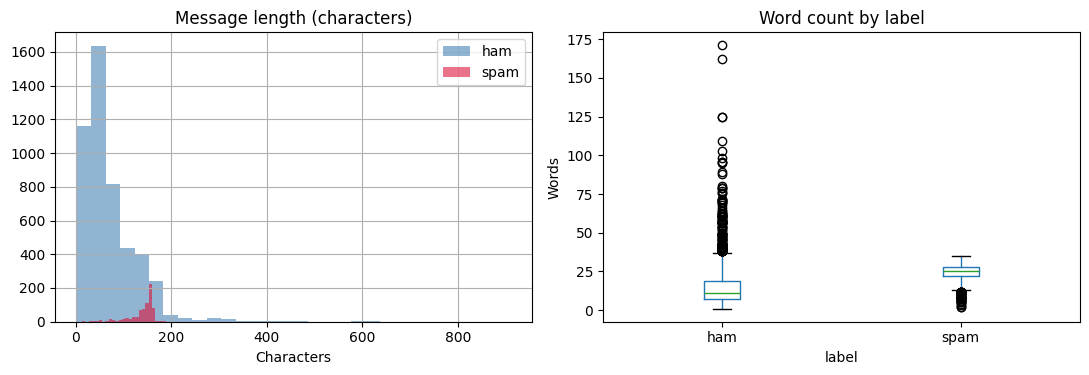

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, color in [('ham', 'steelblue'), ('spam', 'crimson')]:
    axes[0].hist(spam.loc[spam.label == label, 'char_len'], bins=30,
                 alpha=0.6, label=label, color=color)
axes[0].set_title('Message length (characters)')
axes[0].set_xlabel('Characters')
axes[0].legend()

spam.boxplot(column='word_count', by='label', ax=axes[1], grid=False)
axes[1].set_title('Word count by label')
axes[1].set_ylabel('Words')
plt.suptitle('')
plt.tight_layout()
plt.show()

## B.2 Descriptive stats on word frequencies

Another common way to summarize non-rectangular text is a **frequency distribution of words** — essentially a histogram over vocabulary instead of over numbers.

In [ ]:
import re
from collections import Counter

def tokenize(msg):
    return re.findall(r"[a-z']+", msg.lower())

spam_words = Counter(w for msg in spam.loc[spam.label == 'spam', 'message'] for w in tokenize(msg))
ham_words  = Counter(w for msg in spam.loc[spam.label == 'ham',  'message'] for w in tokenize(msg))

# drop very common stopwords for a cleaner picture
stopwords = {'to','you','a','the','i','and','is','in','u','for','my','of','it','me','on','your','are','that','have'}
top_spam = [(w, c) for w, c in spam_words.most_common(30) if w not in stopwords][:10]
top_spam

[('call', 370),
 ('free', 228),
 ('now', 203),
 ('or', 192),
 ('p', 180),
 ('txt', 170),
 ('ur', 144),
 ('from', 132),
 ('mobile', 129),
 ('stop', 128)]

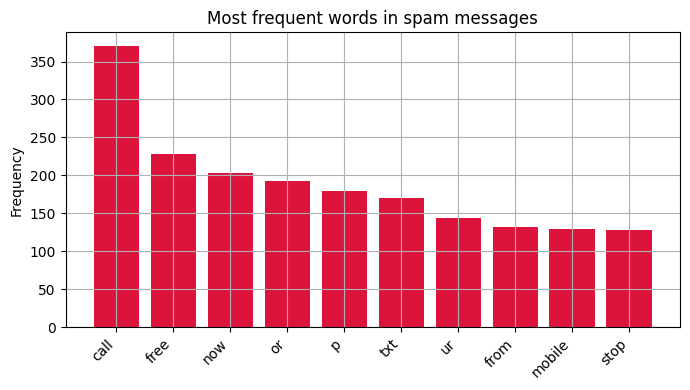

In [ ]:
words, counts = zip(*top_spam)
plt.bar(words, counts, color='crimson')
plt.title('Most frequent words in spam messages')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## B.3 Summary statistics comparison table

A single table that puts the two labels' descriptive stats side by side — the non-rectangular equivalent of Part A's `groupby` summaries.

In [ ]:
summary = spam.groupby('label').agg(
    n_messages   = ('message', 'count'),
    mean_chars   = ('char_len', 'mean'),
    median_chars = ('char_len', 'median'),
    std_chars    = ('char_len', 'std'),
    mean_words   = ('word_count', 'mean'),
    std_words    = ('word_count', 'std'),
).round(2)
summary

,n_messages,mean_chars,median_chars,std_chars,mean_words,std_words
label,,,,,,
ham,4825,71.48,52.0,58.44,14.31,11.52
spam,747,138.67,149.0,28.87,23.91,5.78


---
# Wrap-up exercises

Try these to check your understanding:

1. **Titanic**: Compute the mean, median and standard deviation of `fare` *separately for survivors vs non-survivors*. What does the difference suggest?
2. **Titanic**: Which numeric column has the highest skewness? Plot its histogram to confirm visually.
3. **Spam data**: Compute the proportion of messages containing an exclamation mark `!` for spam vs ham. Does it match your intuition?
4. **Spam data**: Build a frequency bar chart of the top 10 words in *ham* messages and compare it to the spam chart above — what's different?
5. **Challenge**: Compute the *coefficient of variation* (std / mean) for `age` and `fare` in Titanic. Which variable is relatively more spread out?
